In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
import yfinance as yf

In [ ]:
stock = 'RELIANCE.NS'

In [ ]:
data = yf.download(stock, period='10y', interval='1d')

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

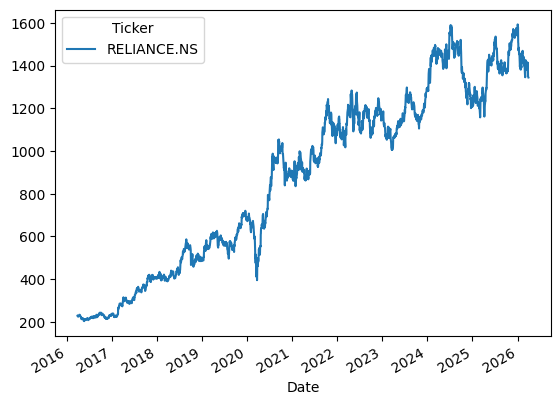

In [4]:
data = data['Close']
data.plot()

In [5]:
def adf(x):
  res = adfuller(x)
  print("Test-Statistic:", res[0])
  print("P-Value:", res[1])
  if res[1] < 0.05:
    print("Stationary")
  else:
    print("Non-Stationary")

In [6]:
adf(data)

Test-Statistic: -1.209398686124466
P-Value: 0.669539622808639
Non-Stationary


In [7]:
data['log_price'] = np.log(data)

In [8]:
adf(data['log_price'])

Test-Statistic: -1.7909603236814542
P-Value: 0.3849587876530825
Non-Stationary


<Axes: xlabel='Date'>

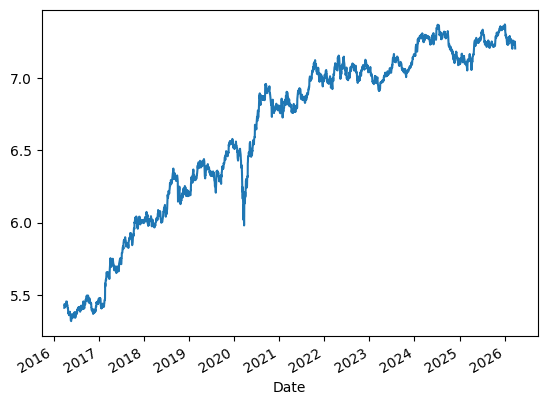

In [9]:
data['log_price'].plot()

In [10]:
data['log_ret'] = data['log_price'].diff()

<Axes: xlabel='Date'>

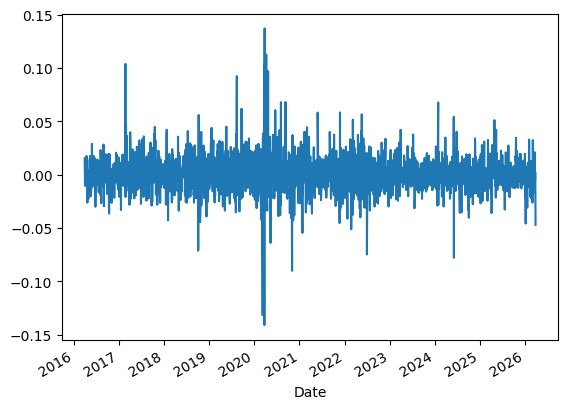

In [11]:
data['log_ret'].plot()

In [13]:
adf(data['log_ret'].dropna())

Test-Statistic: -14.975709914569318
P-Value: 1.1821368750027973e-27
Stationary


In [15]:
adfuller(data['log_ret'].dropna())

(np.float64(-14.975709914569318),
 np.float64(1.1821368750027973e-27),
 10,
 2460,
 {'1%': np.float64(-3.4330110311801567),
  '5%': np.float64(-2.862715621038473),
  '10%': np.float64(-2.5673958300284223)},
 np.float64(-12989.670340547656))

In [19]:
kpss(data['RELIANCE.NS'])

/var/folders/tw/2rqbm49j0kj2wfkk_jh33n440000gn/T/ipykernel_98679/2378735256.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss(data['RELIANCE.NS'])


(np.float64(7.817100257731928),
 np.float64(0.01),
 30,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [21]:
def kpss_helper(df):
    res = kpss(df)
    print('KPSS Test Statistic: ', res[0])
    print('KPSS p-value: ', res[1])
    if res[1] < 0.05:
        print("Non-Stationary")
    else:
        print("Stationary")

In [23]:
kpss_helper(data['RELIANCE.NS'])

KPSS Test Statistic:  7.817100257731928
KPSS p-value:  0.01
Non-Stationary


/var/folders/tw/2rqbm49j0kj2wfkk_jh33n440000gn/T/ipykernel_98679/3486552710.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(df)


In [24]:
kpss_helper(data['log_price'])

KPSS Test Statistic:  7.387795046281578
KPSS p-value:  0.01
Non-Stationary


/var/folders/tw/2rqbm49j0kj2wfkk_jh33n440000gn/T/ipykernel_98679/3486552710.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(df)


In [26]:
kpss_helper(data['log_ret'].dropna())

KPSS Test Statistic:  0.2012912152531023
KPSS p-value:  0.1
Stationary


/var/folders/tw/2rqbm49j0kj2wfkk_jh33n440000gn/T/ipykernel_98679/3486552710.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(df)


In [ ]:
alpha = 0.5

KeyError: 'Close'

In [20]:
play_data = data.copy()

In [21]:
play_data['ewma'] = play_data.ewm(alpha=alpha, adjust=False).mean()

<Axes: xlabel='Date'>

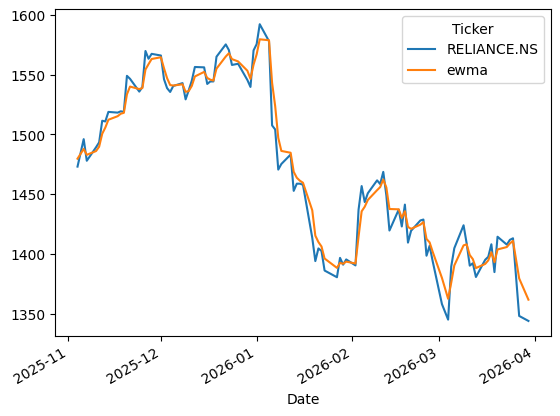

In [22]:
play_data[-100:].plot()

In [ ]:
##GARCH IMPLEMENTATION

In [1]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import numpy as np

In [2]:
data = yf.download("RELIANCE.NS", period='10y', interval='1d')

[*********************100%***********************]  1 of 1 completed


In [3]:
returns = data['Close'].pct_change().dropna()

<Axes: xlabel='Date'>

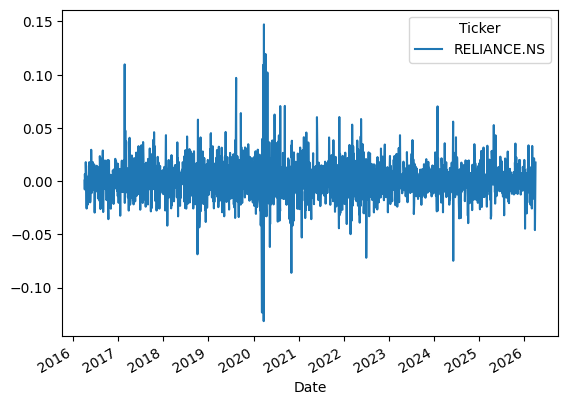

In [8]:
returns.plot()

In [4]:
returns.squeeze()

Date
2016-04-05   -0.007826
2016-04-06    0.006622
2016-04-07    0.003386
2016-04-08   -0.000868
2016-04-11    0.003812
                ...   
2026-03-25    0.000921
2026-03-27   -0.045998
2026-03-30   -0.003115
2026-04-01    0.018826
2026-04-02   -0.013658
Name: RELIANCE.NS, Length: 2469, dtype: float64

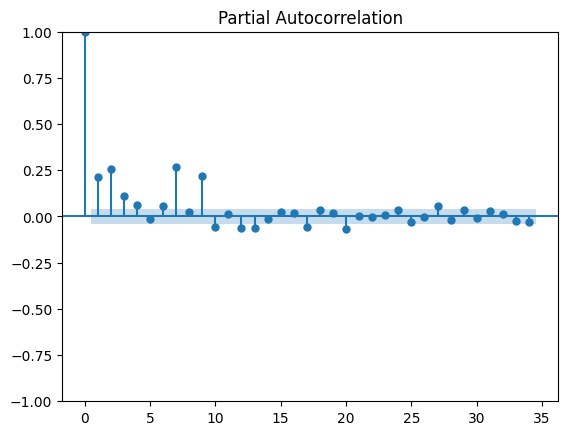

In [5]:
plot_pacf(returns**2)
plt.show()

In [99]:
model = arch_model(returns, p=2, q=2, vol='GARCH', rescale=False)
fitted_model = model.fit()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 7.96701673064302e+18
Iteration:      2,   Func. Count:     22,   Neg. LLF: 1032987.0405340173
Optimization terminated successfully    (Exit mode 0)
            Current function value: -6772.638610365811
            Iterations: 3
            Function evaluations: 31
            Gradient evaluations: 2


In [100]:
fitted_model.summary

<bound method ARCHModelResult.summary of                      Constant Mean - GARCH Model Results                      
Dep. Variable:            RELIANCE.NS   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                6772.64
Distribution:                  Normal   AIC:                          -13533.3
Method:            Maximum Likelihood   BIC:                          -13498.4
                                        No. Observations:                 2469
Date:                Wed, Apr 01 2026   Df Residuals:                     2468
Time:                        15:23:54   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         7.6361

In [106]:
model = arch_model(returns, q=1, rescale=False)
model_fit = model.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 8.794147439874982e+18
Iteration:      2,   Func. Count:     18,   Neg. LLF: 6.879257280292294e+16
Iteration:      3,   Func. Count:     30,   Neg. LLF: 21225300.44492202
Iteration:      4,   Func. Count:     43,   Neg. LLF: 852843844750.5007
Optimization terminated successfully    (Exit mode 0)
            Current function value: -6774.609582273557
            Iterations: 5
            Function evaluations: 53
            Gradient evaluations: 4


In [107]:
model_fit.summary

<bound method ARCHModelResult.summary of                      Constant Mean - GARCH Model Results                      
Dep. Variable:            RELIANCE.NS   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                6774.61
Distribution:                  Normal   AIC:                          -13541.2
Method:            Maximum Likelihood   BIC:                          -13518.0
                                        No. Observations:                 2469
Date:                Wed, Apr 01 2026   Df Residuals:                     2468
Time:                        15:24:56   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         7.6669

In [10]:
rolling_preds = []
test_size = 365*5

for i in range(test_size):
    train = returns[:-(test_size-i)]
    model = arch_model(train,p=1, q=1, rescale=False)
    model_fit = model.fit(disp='off', options={'maxiter': 1000})
    pred = model_fit.forecast(horizon=1)
    rolling_preds.append(np.sqrt(pred.variance.values[-1,:][0]))

In [11]:
rolling_preds = pd.Series(rolling_preds, index=returns.index[-365*5:])

Text(0.5, 1.0, 'Vol pred - rolling forecast')

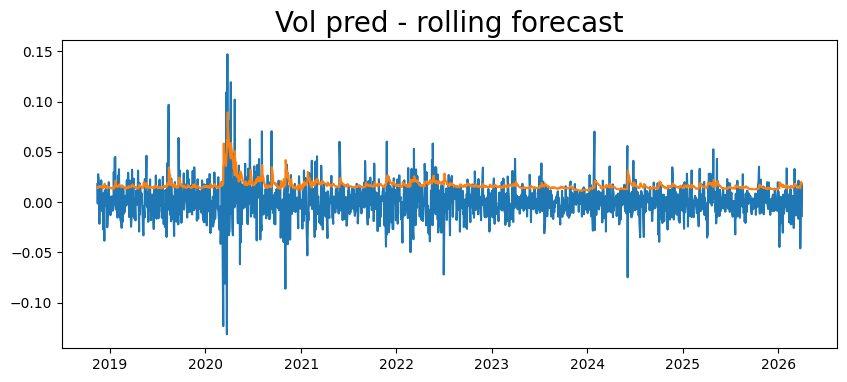

In [12]:
plt.figure(figsize=(10,4))
true, = plt.plot(returns[-365*5:])
preds, = plt.plot(rolling_preds)
plt.title('Vol pred - rolling forecast', fontsize=20)

In [20]:
model = arch_model(returns, p=1, q=1, rescale=False)
result = model.fit(options={'maxiter': 1000})

Iteration:      1,   Func. Count:      6,   Neg. LLF: 8.437838029243265e+18
Iteration:      2,   Func. Count:     18,   Neg. LLF: 101437359.77352765
Iteration:      3,   Func. Count:     31,   Neg. LLF: 233452449309724.22
Iteration:      4,   Func. Count:     42,   Neg. LLF: 58730531401.14304
Iteration:      5,   Func. Count:     56,   Neg. LLF: 68973270237.64874
Iteration:      6,   Func. Count:     64,   Neg. LLF: 2738403195766.592
Iteration:      7,   Func. Count:     77,   Neg. LLF: -6774.203452525595
Optimization terminated successfully    (Exit mode 0)
            Current function value: -6774.20345566576
            Iterations: 11
            Function evaluations: 77
            Gradient evaluations: 7


In [21]:
result.summary

<bound method ARCHModelResult.summary of                      Constant Mean - GARCH Model Results                      
Dep. Variable:            RELIANCE.NS   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                6774.20
Distribution:                  Normal   AIC:                          -13540.4
Method:            Maximum Likelihood   BIC:                          -13517.2
                                        No. Observations:                 2469
Date:                Fri, Apr 03 2026   Df Residuals:                     2468
Time:                        14:30:46   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         7.6398

In [22]:
# 1. Get the full parameters table as a DataFrame
params = result.params           # Coefficients
pvalues = result.pvalues         # P-values
tvalues = result.tvalues         # t-statistics
std_err = result.std_err         # Standard errors
conf_int = result.conf_int()     # 95% Confidence intervals (DataFrame)

# Combine into one clean DataFrame
summary_df = pd.DataFrame({
    'coef': params,
    'std_err': std_err,
    't_stat': tvalues,
    'p_value': pvalues,
    'ci_lower': conf_int['lower'],
    'ci_upper': conf_int['upper']
})

print(summary_df)

              coef       std_err     t_stat        p_value  ci_lower  ci_upper
mu        0.000764  2.860459e-04   2.670820   7.566627e-03  0.000203  0.001325
omega     0.000029  9.879731e-07  29.092439  4.474359e-186  0.000027  0.000031
alpha[1]  0.099802  2.166002e-02   4.607653   4.072390e-06  0.057349  0.142255
beta[1]   0.798415  1.531238e-02  52.141774   0.000000e+00  0.768403  0.828426


In [23]:
alpha_terms = summary_df[summary_df.index.str.startswith('alpha')]
beta_terms  = summary_df[summary_df.index.str.startswith('beta')]

print("ARCH (alpha) terms:\n", alpha_terms)
print("\nGARCH (beta) terms:\n", beta_terms)

ARCH (alpha) terms:
               coef  std_err    t_stat   p_value  ci_lower  ci_upper
alpha[1]  0.099802  0.02166  4.607653  0.000004  0.057349  0.142255

GARCH (beta) terms:
              coef   std_err     t_stat  p_value  ci_lower  ci_upper
beta[1]  0.798415  0.015312  52.141774      0.0  0.768403  0.828426


In [24]:
garch_terms = summary_df[
    summary_df.index.str.startswith('alpha') |
    summary_df.index.str.startswith('beta')
]

all_significant = (garch_terms['p_value'] < 0.05).all()

if all_significant:
    print("✅ All GARCH parameters are significant.")
else:
    insignificant = garch_terms[garch_terms['p_value'] >= 0.05]
    print("❌ Insignificant parameters found:")
    print(insignificant[['coef', 'p_value']])

✅ All GARCH parameters are significant.
